In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/panel/marz_year_panel_common.csv"
)

In [2]:
df.shape


(70, 24)

In [3]:
df.columns


Index(['marz', 'year', 'poverty_rate', 'extreme_poverty_rate', 'non_poor_rate',
       'population', 'crime_selected_total', 'Number of minor offense',
       'Number of moderately serious offense',
       'Number of particulary serious offences', 'crime_total',
       'Number of serious offences', 'Annual average occupancy of a bed',
       'Number of ambulatory clinics in rural communities',
       'Number of avarage medical personnel', 'beds',
       'Number of hospitalized patients', 'hospitals', 'Number of physicians',
       'Number of primary health care (PHC) service providers (except OMCs, private medical and dental offices)',
       'crime_rate_per_100k', 'crime_selected_rate_per_100k',
       'hospitals_per_100k', 'beds_per_10k'],
      dtype='object')

In [4]:
df.head()

,marz,year,poverty_rate,extreme_poverty_rate,non_poor_rate,population,crime_selected_total,Number of minor offense,Number of moderately serious offense,Number of particulary serious offences,...,Number of avarage medical personnel,beds,Number of hospitalized patients,hospitals,Number of physicians,"Number of primary health care (PHC) service providers (except OMCs, private medical and dental offices)",crime_rate_per_100k,crime_selected_rate_per_100k,hospitals_per_100k,beds_per_10k
0,Yerevan,2016,24.9,1.9,75.1,1073660.0,4085.0,4527.0,2917.0,95.0,...,8654.0,7924.0,279477.0,53.0,9504.0,147.0,869.828437,380.474266,4.936386,73.803625
1,Aragatsotn,2016,15.7,0.6,84.3,129774.0,191.0,322.0,259.0,4.0,...,633.0,200.0,5376.0,6.0,241.0,24.0,504.723596,147.178942,4.623422,15.411408
2,Ararat,2016,26.9,1.0,73.1,258911.0,349.0,647.0,417.0,4.0,...,1005.0,473.0,13693.0,7.0,460.0,60.0,473.135556,134.795354,2.703632,18.268826
3,Armavir,2016,30.0,1.5,70.0,266613.0,373.0,651.0,457.0,11.0,...,975.0,355.0,13364.0,4.0,403.0,61.0,490.598733,139.903156,1.500302,13.315180
4,Lori,2016,35.8,2.7,64.0,224954.0,383.0,747.0,399.0,15.0,...,1167.0,486.0,18593.0,8.0,514.0,42.0,580.118602,170.257030,3.556283,21.604417


In [5]:
df.describe()[[
    "poverty_rate",
    "crime_rate_per_100k",
    "hospitals_per_100k",
    "beds_per_10k"
]]

,poverty_rate,crime_rate_per_100k,hospitals_per_100k,beds_per_10k
count,70.000000,70.000000,70.000000,70.000000
mean,26.002857,722.226161,4.336102,26.694441
std,10.680484,276.569849,1.556740,17.239148
min,2.800000,348.178456,1.134717,11.954761
25%,18.600000,544.494132,3.227489,17.183668
50%,24.550000,651.747139,4.758013,19.551620
75%,32.650000,836.155807,5.611981,30.912582
max,51.400000,1976.979771,6.686783,77.258437


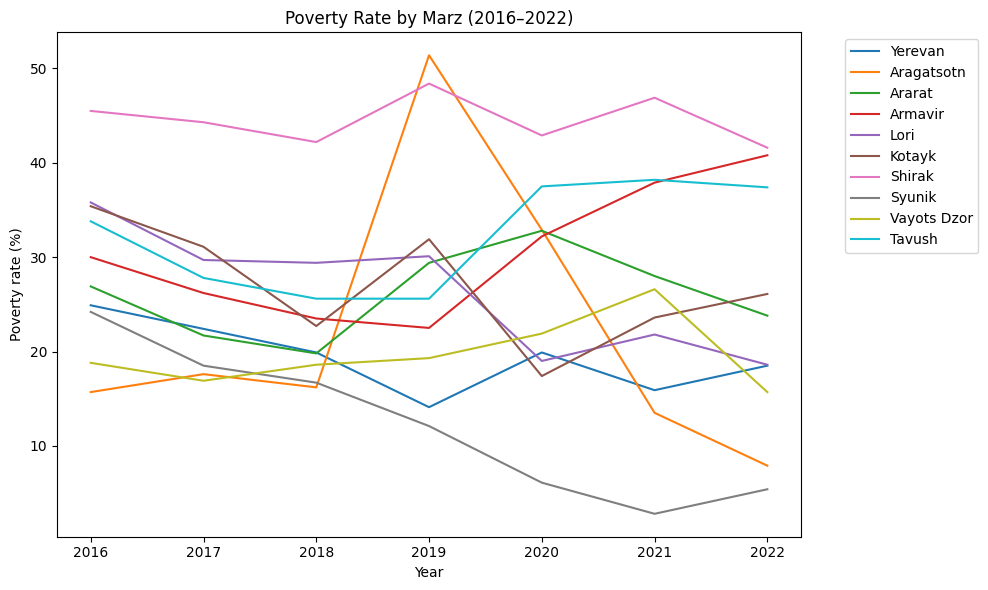

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for marz in df["marz"].unique():
    subset = df[df["marz"] == marz]
    plt.plot(subset["year"], subset["poverty_rate"], label=marz)

plt.title("Poverty Rate by Marz (2016–2022)")
plt.xlabel("Year")
plt.ylabel("Poverty rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


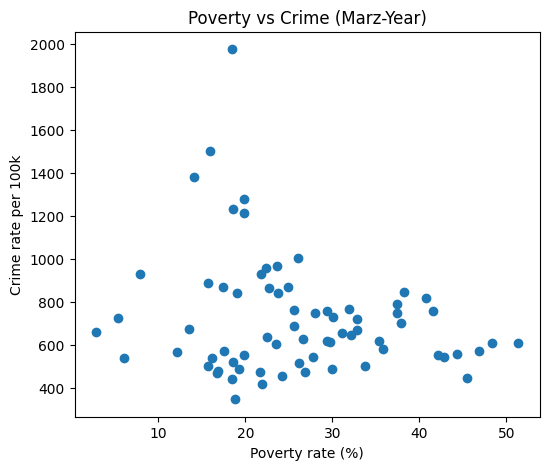

In [7]:
plt.figure(figsize=(6,5))
plt.scatter(df["poverty_rate"], df["crime_rate_per_100k"])

plt.xlabel("Poverty rate (%)")
plt.ylabel("Crime rate per 100k")
plt.title("Poverty vs Crime (Marz-Year)")
plt.show()


In [8]:
df[["poverty_rate", "crime_rate_per_100k"]].corr()


,poverty_rate,crime_rate_per_100k
poverty_rate,1.000000,-0.203902
crime_rate_per_100k,-0.203902,1.000000


In [9]:
from scipy.stats import zscore

df_stress = df.copy()

df_stress["z_poverty"] = zscore(df_stress["poverty_rate"])
df_stress["z_crime"] = zscore(df_stress["crime_rate_per_100k"])
df_stress["z_hospitals"] = zscore(df_stress["hospitals_per_100k"])

# invert health (higher capacity = less stress)
df_stress["z_health_inverted"] = -df_stress["z_hospitals"]


In [10]:
df_stress["stress_index"] = (
    df_stress["z_poverty"]
    + df_stress["z_crime"]
    + df_stress["z_health_inverted"]
)

# optional normalization (nice, not required)
df_stress["stress_index"] = zscore(df_stress["stress_index"])


In [11]:
df_stress.sort_values("stress_index", ascending=False).head(10)[
    ["marz", "year", "stress_index"]
]


,marz,year,stress_index
63,Armavir,2022,2.362242
60,Yerevan,2022,2.003083
53,Armavir,2021,1.778313
64,Lori,2022,1.324922
43,Armavir,2020,1.322498
42,Ararat,2020,1.200347
52,Ararat,2021,1.133971
62,Ararat,2022,1.104054
31,Aragatsotn,2019,1.049196
50,Yerevan,2021,0.859293


In [12]:
df_stress.sort_values("stress_index").head(10)[
    ["marz", "year", "stress_index"]
]


,marz,year,stress_index
8,Vayots Dzor,2016,-1.892009
47,Syunik,2020,-1.875023
57,Syunik,2021,-1.824215
18,Vayots Dzor,2017,-1.737877
48,Vayots Dzor,2020,-1.665803
38,Vayots Dzor,2019,-1.637364
28,Vayots Dzor,2018,-1.573803
67,Syunik,2022,-1.541490
37,Syunik,2019,-1.458986
27,Syunik,2018,-1.404199


In [13]:
df_stress.groupby("marz")["stress_index"].mean().sort_values(ascending=False)


marz
Armavir        1.206841
Lori           0.696138
Yerevan        0.683733
Ararat         0.631222
Kotayk         0.376515
Shirak         0.061108
Tavush        -0.240333
Aragatsotn    -0.430001
Syunik        -1.490790
Vayots Dzor   -1.494432
Name: stress_index, dtype: float64

In [14]:
df_stress.to_csv(
    "../data/processed/panel/marz_year_panel_common_with_stress.csv",
    index=False
)
